# Running and Interpreting CIGALE

In the previous notebooks, we have prepared multiwavelength imaging for NGC 4321, measured surface brightness profiles, and extracted aperture photometry. In *this* notebook, we'll learn how to use that photometry as input to **CIGALE**, the **Code Investigating GALaxy Emission**. There are tons of references and papers about CIGALE: 
- Here is the CIGALE website: https://cigale.lam.fr/
- There are several papers that track the development of CIGALE through the years: [Burgarella et al. (2005)](https://scixplorer.org/abs/2005MNRAS.360.1413B/abstract), [Noll et al. (2009)](https://scixplorer.org/abs/2009A%26A...507.1793N/abstract), [Boquien et al. (2019)](https://scixplorer.org/abs/2019A%26A...622A.103B/abstract), and [Burgarella et al. (2025)](https://scixplorer.org/abs/2025A%26A...699A.336B/abstract). 
- The GitLab repository has a useful manual: https://gitlab.lam.fr/cigale/manual/

Now, what does CIGALE do? CIGALE compares observed galaxy photometry to models of stars, gas, dust, and AGN to infer physical properties of a galaxy, such as stellar mass, star formation rate (SFR), dust attenuation, dust luminosity, AGN contribution, etc. It does this by constructing a *spectral energy distribution* (SED), a measurement of how bright an object is as a function of wavelength. Remember from our original look at the multiwavelength imaging that different wavelengths in galaxies come from different components: 
- UV light traces young massive stars and star-forming regions;
- Optical light traces a mixture of young and old stars, as well as star-forming regions; 
- Near-infrared light traces older stars;
- Mid-infrared light traces warm dust and PAH emission; 
- Far-infrared light traces colder dust.

To fully understand a galaxy, we need images that capture all of this light (as well as maybe x-ray and radio data too). 

This notebook has two parts: 
1. A conceptual and practical guide to installing, configuring, and running CIGALE; and
2. Python code to read and visualize the outputs of a completed CIGALE run. 

In [1]:
# Numerical tools
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# File and path handling
from pathlib import Path
import shutil

# Astropy tables and FITS files
from astropy.table import Table, QTable
from astropy.io import fits

# Astropy units
import astropy.units as u

# Plotting configuration
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['font.size'] = 12

## 1. How to Install CIGALE

It's a good idea to install CIGALE in its own `conda` environment. The official documentation, located [here](https://cigale.lam.fr/documentation/), gives a step-by-step installation using a `conda` environment. The broad idea is: 
1. Create a clean `conda` environment.
2. Install CIGALE dependencies. 
3. Download the CIGALE source code. 
4. Build the CIGALE database. 
5. Install CIGALE in editable mode. 

We do this all in a new `conda` environment because CIGALE has specific dependencies, and we don't want to screw up our standard Python installation. 

### Installation 

I'm basically copying this from the official documentation, mainly just in case they delete that webpage, we still know how to install it. 

1. Download the latest CIGALE source from the [download page](https://cigale.lam.fr/download/). Extract the downloaded archive wherever you want CIGALE to live. For me, this is on an external hardrive with a lot of space. For you, it might be just on your computer's hardrive. Just be aware that your computer will slow down as the installation proceeds. 
2. Open up your Terminal and create a `conda` environment in which we'll install CIGALE: 
    ```bash
    conda create -n cigale python=3.12
    ```
3. Activate this environment, which you'll need to do at the beginning of every session when you want to use CIGALE: 
    ```bash
    conda activate cigale
    ````
4. Install some of the CIGALE dependencies using `conda`: 
    ```bash
    conda install astropy numpy scipy matplotlib configobj setuptools rich
    ```
    Note that for new versions of `Anaconda`, `configobj` might not be available. If that's the case, do `pip install configobj` instead. Also, as of writing, `numpy` is on version 2.4.0 and CIGALE was written using an older version of `numpy`. The only thing this changes is that `np.trapz` has been updated to `np.trapezoid`. You can either use an older version of `numpy` or manually change all occurrences of `np.trapz` in the `database_builder/` folder. 
5. In your Terminal shell, go inside your CIGALE source folder (`cd /path/to/cigale`) and build the CIGALE database with
    ```bash
    python setup.py build
    ```
6. Finally, install CIGALE in the environment: 
    ```bash
    python -m pip install e .
    ```

*Voilà!* CIGALE is now installed on your computer. Whenever you need to use it, launch a Terminal shell, activate the `conda` environment with `conda activate cigale` and you will have access to CIGALE commands. 

## 2. General CIGALE Workflow

A typical CIGALE run proceeds like this: 
```bash
pcigale init
pcigale genconf
pcigale check
pcigale run
```
The commands do the following: 
| Command           | Purpose                                                                 |
|-------------------|-------------------------------------------------------------------------|
| `pcigale init`    | Create the initial `pcigale.ini` and `pcigale.ini.spec` files.          |
| `pcigale genconf` | Expand the configuration file with parameters for the selected modules. |
| `pcigale check`   | Check the configuration and report how many models will be computed.    |
| `pcigale run`     | Run the SED fitting.                                                    |

The most important file is `pcigale.ini`. This file tells CIGALE which photometry table to read, which SED modules to use, which model parameters to explore, which photometric bands to fit, which physical parameters to estimate, and whether to save products and which ones. 

The initial configuration file is where you tell it where the input data is located, the list of SED modules, and the analysis method. `genconf` then adds the configuration sections for the seelcted modules and analysis methods in the same file. 

## 3. CIGALE Input Photometry File

CIGALE expects a photometry table with: 
- `id`: object identifier,
- `redshift`: object redshift,
- optionally `distance`: distance in Mpc for nearby galaxies,
- one flux column per filter
- one uncertainty column per filter, with `_err` appended. 

For example: 

```text
id redshift distance galex.FUV galex.FUV_err galex.NUV galex.NUV_err ...
NGC4321 0.0 15.8 ...
```
You can find a list of filter names by running `pcigale-filters list` in the Terminal. For broadband photometry, fluxes and uncertainties should be in mJy. 

In [81]:
# Directory from Notebook 3
photometry_dir = Path('NGC4321_AperturePhotometry')

# CIGALE input file made in Notebook 3
cigale_input_file = photometry_dir / 'NGC4321_cigale_input.txt'

# Full photometry table from Notebook 3
full_photometry_file = photometry_dir / 'NGC4321_aperture_photometry.ecsv'

# Directory where we will set up the CIGALE run
cigale_run_dir = Path('cigale_run')

# Output directory created by CIGALE after running
cigale_out_dir = cigale_run_dir / 'out'

# CIGALE observation file
# CIGALE has the option of adding extra uncertainty to the observed fluxes, so we want these values
cigale_obs_file = cigale_out_dir / 'observations.fits'

print(f'CIGALE input file: {cigale_input_file}')
print(f'CIGALE run directory: {cigale_run_dir}')

CIGALE input file: NGC4321_AperturePhotometry/NGC4321_cigale_input.txt
CIGALE run directory: cigale_run


In [3]:
# Read the CIGALE input file
cigale_input = Table.read(cigale_input_file, format='ascii.basic')

cigale_input

id,redshift,distance,galex.FUV,galex.FUV_err,galex.NUV,galex.NUV_err,sloan.sdss.u,sloan.sdss.u_err,sloan.sdss.g,sloan.sdss.g_err,sloan.sdss.r,sloan.sdss.r_err,sloan.sdss.i,sloan.sdss.i_err,sloan.sdss.z,sloan.sdss.z_err,2mass.J,2mass.J_err,2mass.H,2mass.H_err,2mass.Ks,2mass.Ks_err,spitzer.irac.I1,spitzer.irac.I1_err,spitzer.irac.I2,spitzer.irac.I2_err,spitzer.irac.I3,spitzer.irac.I3_err,spitzer.irac.I4,spitzer.irac.I4_err,spitzer.mips.24mu,spitzer.mips.24mu_err,spitzer.mips.160mu,spitzer.mips.160mu_err,wise.W1,wise.W1_err,wise.W2,wise.W2_err,wise.W3,wise.W3_err,wise.W4,wise.W4_err
str7,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
NGC4321,0.0,15.8,30.81282132848724,1.3866273554943198,52.98584202047065,1.4306944172764422,178.27093313993845,2.3309062552220547,468.76137288090837,3.751319270449277,782.3589852685625,6.260626554493529,1056.8051856639531,7.401604930039014,1213.102908240968,9.73740401172521,1587.5526725754069,27.096792773722676,1715.5382731768525,32.8608013773628,1527.8591949918095,29.298166900122624,964.3310728784578,28.93013377287502,624.3607271010943,18.731364669980444,1427.7846945051272,42.83895288786623,3388.894916750028,101.67092639207894,3382.0001702832806,169.10359606226098,116886.71694098745,14026.567753119496,907.9352005381191,26.33050722913436,562.7516354458583,19.13413469981618,2479.0179171533746,114.03573210384826,3766.4545903596195,210.9251872933513


In [4]:
# Let's make sure we have a properly formatted input file.

# Check that the input table has the expected basic columns
required_columns = ['id', 'redshift']

for col in required_columns:
    if col not in cigale_input.colnames:
        raise ValueError(f'Missing required CIGALE column: {col}')
    
# Identify flux columns and uncertainty columns
metadata_columns = ['id', 'redshift', 'distance']

flux_columns = []
error_columns = []

for col in cigale_input.colnames:
    if col in metadata_columns:
        continue

    if col.endswith('_err'):
        error_columns.append(col)
    else:
        flux_columns.append(col)

print('Flux columns:')
print(flux_columns)

print('\nUncertainty columns:')
print(error_columns)

# Check that every flux column has a matching uncertainty column
missing_errors = []

for flux_col in flux_columns:
    expected_error_col = flux_col + '_err'

    if expected_error_col not in cigale_input.colnames:
        missing_errors.append(expected_error_col)

if len(missing_errors) == 0:
    print('\nEvery flux column has a matching uncertainty column.')
else:
    print('\nMissing uncertainty columns:')
    print(missing_errors)

Flux columns:
['galex.FUV', 'galex.NUV', 'sloan.sdss.u', 'sloan.sdss.g', 'sloan.sdss.r', 'sloan.sdss.i', 'sloan.sdss.z', '2mass.J', '2mass.H', '2mass.Ks', 'spitzer.irac.I1', 'spitzer.irac.I2', 'spitzer.irac.I3', 'spitzer.irac.I4', 'spitzer.mips.24mu', 'spitzer.mips.160mu', 'wise.W1', 'wise.W2', 'wise.W3', 'wise.W4']

Uncertainty columns:
['galex.FUV_err', 'galex.NUV_err', 'sloan.sdss.u_err', 'sloan.sdss.g_err', 'sloan.sdss.r_err', 'sloan.sdss.i_err', 'sloan.sdss.z_err', '2mass.J_err', '2mass.H_err', '2mass.Ks_err', 'spitzer.irac.I1_err', 'spitzer.irac.I2_err', 'spitzer.irac.I3_err', 'spitzer.irac.I4_err', 'spitzer.mips.24mu_err', 'spitzer.mips.160mu_err', 'wise.W1_err', 'wise.W2_err', 'wise.W3_err', 'wise.W4_err']

Every flux column has a matching uncertainty column.


## 4. Set Up a CIGALE Run Directory

It's useful to keep things organized, so we'll run CIGALE in a separate directory. Inside that directory, we'll place the CIGALE input photometry file, the generated `pcigale.ini` file, and the CIGALE output directory. 

The next cell creates the run directory and copies the input photometry file into it. 

In [6]:
# Create the run directory if it does not exist
cigale_run_dir.mkdir(exist_ok=True)

# Copy the photometry input file into the run directory
run_input_file = cigale_run_dir / cigale_input_file.name

shutil.copy(cigale_input_file, run_input_file)

print(f'Copied input photometry to: {run_input_file}')

Copied input photometry to: cigale_run/NGC4321_cigale_input.txt


## 5. Initialize CIGALE

The next step happens in the Terminal. Move into the CIGALE run directory:
```bash
cd cigale_run
```
Then initialize the run:
```bash
pcigale init
```
This creates the initial `pcigale.ini` file. At this stage, `pcigale.ini` is fairly short. You'll edit it in your favorite text editor to tell CIGALE the data file, the SED modules you want to use, the analysis method, and the number of CPU cores. 

## 6. First Edit to `pcigale.ini`

After running `pcigale init`, now we have to edit `pcigale.ini`. It'll look something like this: 

```ini
# File containing the input data. The columns are:
# * 'id': name of the object.
# * 'redshift': redshift of the object. If 0, the distance is assumed to
# be 10 pc. If negative the photometric mode is enabled. In that case an
# explicit redshift grid must be provided in the redshfting module.
# * 'distance' (Mpc, optional): distance in Mpc. Optional, if present it
# will be used in lieu of the distance computed from the redshift
# assuming a Planck et al. (2018) cosmology.
# * band fluxes: fluxes in filters in mJy. Each column is identified
# with a unique filter name, for instance jwst.nircam.F200W for the 2 μm
# filter of the NIRCAM instrument onboard JWST. The known filters are
# avalaible from the command 'pcigale-filters list'.
# * line fluxes: fluxes in lines in W/m². Each column is identified
# after a unique line name prefixed with 'line.', for instance
# line.H-alpha. The known filters are available from the command
# 'pcigale-filters list'. It is possible to combine lines together, for
# instance line.NII-654.8+H-alpha+NII-658.3 will be the sum of Hα and
# the adjacent NII lines.
# * physical properties: values of the intensive and extensive physical
# properties (e.g., dust.luminosity for the dust luminosity). To
# determine the format of the columns and the units, it is suggested to
# do a minimal run and examine the output FITS table.
# * uncertainties: the uncertainties for the band and line fluxes as
# well as for the physical properties are given using the same column
# names with the '_err' suffix.
# Important notes:
# * Fluxes can be positive or negative.
# * Upper limits are indicated with a negative value for the
# uncertainty.
# * In case some fluxes are missing for some objects, they can be
# replaced with NaN.
# * This file is optional to generate the configuration file, in
# particular for the savefluxes module.
data_file = NGC4321_cigale_input.txt

# Optional file containing the list of physical parameters. Each column
# must be in the form module_name.parameter_name, with each line being a
# different model. The columns must be in the order the modules will be
# called. The redshift column must be the last one. Finally, if this
# parameter is not empty, cigale will not interpret the configuration
# parameters given in pcigale.ini. They will be given only for
# information. Note that this module should only be used in conjonction
# with the savefluxes module. Using it with the pdf_analysis module will
# yield incorrect results.
parameters_file = 

# Available modules to compute the models. The order must be kept.
# SFH:
# * sfh2exp: double exponential.
# * sfhdelayed: delayed SFH with optional exponential burst.
# * sfhdelayedbq: delayed SFH with optional constant burst/quench.
# * sfhfromfile: arbitrary SFH read from an input file.
# * sfhperiodic: periodic SFH, exponential, rectangle or delayed.
# SSP:
# * bc03: Bruzual and Charlot 2003.
# * cb19: Charlot and Bruzual 2019.
# * bpassv2: BPASS 2.2
# * m2005: Maraston 2005.
# Nebular emission:
# * nebular: continuum and line nebular emission.
# Dust attenuation:
# * dustatt_modified_CF00: modified Charlot & Fall 2000 attenuation law.
# * dustatt_modified_starburst: modified Calzetti 2000 attenuaton law.
# Dust emission:
# * casey2012: Casey 2012 dust emission models.
# * dale2014: Dale et al. 2014 dust emission templates.
# * dl2007: Draine & Li 2007 dust emission models.
# * dl2014: Draine et al. 2014 update of the previous models.
# * themis: Themis dust emission models from Jones et al. (2017).
# AGN:
# * skirtor2016: AGN models from Stalevski et al. (2012, 2016).
# * fritz2006: AGN models from Fritz et al. (2006).
# X-ray:
# * yang20 (X-ray models from Yang et al. 2020).
# * lopez24 (X-ray models from Lopez et al. 2024).
# Radio:
# * radio: galaxy synchrotron emission and AGN; note:
# skirtor2016/fritz2006 is needed for AGN.
# Restframe parameters:
# * restframe_parameters: UV slope (β), IRX, D4000, equivalent width,
# etc.
# Redshift+IGM:
# * redshifting: mandatory, also includes the IGM from Meiksin (2006).
sed_modules = sfh2exp, bc03, nebular, dustatt_modified_starburst, dl2014, restframe_parameters, redshifting

# Method used for statistical analysis. Available methods: pdf_analysis,
# savefluxes.
analysis_method = pdf_analysis

# Number of CPU cores to use in parallel.
cores = 12
```

The folks who wrote CIGALE are very clever and they list out all of the SED modules you can pick from as well as some last checks on what your input photometry file should contain. 

## 7. What Each Selected Module Means

For this tutorial, we'll use 

```text
sed_modules = sfh2exp, bc03, nebular, dustatt_modified_starburst, dl2014, restframe_parameters, redshifting
```

These modules represent a reasonable model for a normal nearby star-forming spiral galaxy. 

### `sfh2exp`
This module describes the galaxy's star formation history (SFH). This is a double exponential SFH: the first exponential models the long-term star formation that has formed the bulk of the stellar mass of the galaxy, while the second exponential models the most recent burst of star formation. 

Important parameters include: 
| Parameter   | Definition                                                |
|-------------|-----------------------------------------------------------|
| `tau_main`  | Timescale of the main stellar population in Myr.          |
| `age_main`  | Age of the main stellar population in Myr.                |
| `tau_burst` | Timescale of the recent burst in Myr.                     |
| `age_burst` | Age of the recent burst in Myr.                           |
| `f_burst`   | Fraction of the current stellar mass formed in the burst. |
| `normalise` | Whether to normalize the SFH to one solar mass.           |

For NGC 4321, a spiral galaxy with strong ongoing star formation, we'll use a range of old main-population ages and modest recent burst fractions. 

### `bc03`
This module creates the stellar population spectrum. `bc03` refers to the [Bruzual & Charlot (2003)](https://scixplorer.org/abs/2003MNRAS.344.1000B/abstract) stellar population synthesis moels. 

Important parameters include: 
| Parameter        | Definition                                                                    |
|------------------|-------------------------------------------------------------------------------|
| `imf`            | Initial Mass Function. Use `0` for a Salpeter IMF and `1` for a Chabrier IMF. |
| `metallicity`    | Stellar metallicity.                                                          |
| `separation_age` | Age boundary separating young and old stellar populations.                    |

### `nebular`
The most massive stars emit a significant fraction of their light in the ultraviolet. These high-energy photons ionize the surrounding gas which re-emits the energy in the form of a series of emission lines and a continuum. This emission is important because it directly reflects the most recent star formation. 

Important parameters include:
| Parameter     | Definition                                        |
|---------------|---------------------------------------------------|
| `logU`        | Ionization parameter.                             |
| `zgas`        | Gas metallicity.                                  |
| `ne`          | Electron density                                  |
| `f_esc`       | Fraction of ionizing photons escaping the galaxy. |
| `f_dust`      | Fraction of ionizing photons absorbed by dust.    |
| `lines_width` | Width of emission lines in km/s.                  |
| `emission`    | Whether to include nebular emission.              |
| `line_list`   | List of lines for which to save the fluxes.       |

### `dustatt_modified_starburst`
Galaxies contain dust, and this dust is very efficient at absorbing short-wavelength light. The energy absorbed from the UV to the NIR is then re-emitted in the mid- and far-IR. Except for a handful of very nearby objects, observers only see the effect of attenuation, so we need to assume an attenuation law, i.e., how the dust absorbs light. 

Important parameters include:
| Parameter                | Definition                                                               |
|--------------------------|--------------------------------------------------------------------------|
| `E_BV_lines`             | The color excess of the nebular lines.                                   |
| `E_BV_factor`            | The reduction factor to apply to `E_BV_lines` to compute `E_BV_stellar`. |
| `uv_bump_wavelength`     | Central wavelength of the UV bump in nm.                                 |
| `uv_bump_width`          | Width of the UV bump in nm.                                              |
| `uv_bump_amplitude`      | Amplitude of the UV bump.                                                |
| `powerlaw_slope`         | Slope of the power law modifying the attenuation curve.                  |
| `Ext_law_emission_lines` | Extinction law to use.                                                   |
| `Rv`                     | Ratio of the total to selective extinction.                              |
| `filters`                | Filters for which the attenuation will be computed.                      |

### `dl2014`
As dust absorbs photons from the UV to the NIR, this energy is re-emitted at longer wavelengths, essentially in the mid- and far-IR. In general, dust emission is separated into three components: PAHs, small warm dust grains, and large cold dust grains. There's a lot of active research in this area of deciding how to model dust emission. We'll use the [Draine et al. (2014)](https://scixplorer.org/abs/2014ApJ...780..172D/abstract) updates of the original [Draine & Li (2007)](https://scixplorer.org/abs/2007ApJ...657..810D/abstract) models. 

Important parameters include:
| Parameter | Definition                                  |
|-----------|---------------------------------------------|
| `qpah`    | Mass fraction of PAHs.                      |
| `umin`    | Minimum radiation field.                    |
| `alpha`   | Power law slope.                            |
| `gamma`   | Fraction illuminated from `umin` to `umax`. |

### `restframe_parameters`
The previous modules have allowed us to build a full FUV-to-FIR spectrum. There are many quantities that can only be accurately computed from the full spectrum. 

Important parameters include: 
| Parameter            | Definition                                    |
|----------------------|-----------------------------------------------|
| `beta_calz94`        | Observed UV slope.                            |
| `Dn4000`             | 4000 Å break, sensitive to age.               |
| `IRX`                | Ratio of the dust to FUV luminosities.        |
| `EW`                 | Equivalent width of specific emission lines.  |
| `luminosity_filters` | Filters to calculate rest-frame luminosities. |
| `colours_filters`    | Rest-frame colors to calculate.               |

### `redshifting`
This module redshifts the model SED and computes fluxes in the observed filters. 

There's only one parameter here: 
| Parameter  | Definition                                                                |
|------------|---------------------------------------------------------------------------|
| `redshift` | Redshift to use. If blank, CIGALE reads the redshift from the input file. |

For a nearby galaxy where we provide a distance column, we can leave this blank and use the input file. 

## 8. Generate the Full Configuration File

After editing the initial `pcigale.ini` to tell CIGALE which modules we'd like to run, run the following in the Terminal: 
```bash
pcigale genconf
```
This expands the configuration file to allow you to input parameter values to try. The file will also now have comments that tell you a bit more about what each input means and if there are any restricted values. For example, the `sfh2exp` section looks like

```ini 
  [[sfh2exp]]
    # e-folding time of the main stellar population model in Myr.
    tau_main = 
    # e-folding time of the late starburst population model in Myr.
    tau_burst = 
    # Mass fraction of the late burst population.
    f_burst = 
    # Age of the main stellar population in the galaxy in Myr. The precision
    # is 1 Myr.
    age = 
    # Age of the late burst in Myr. The precision is 1 Myr.
    burst_age = 
    # Value of SFR at t = 0 in M_sun/yr.
    sfr_0 = 
    # Normalise the SFH to produce one solar mass.
    normalise = 
```

## 9. Suggested Parameter Grid

I would highly recommend you check out the file `pcigale.ini` located in this directory. There you'll see my choices for exploring the parameter space to fit the SED of NGC 4321. I picked a few sets initially, then slowly expanded the parameter space to make sure I wasn't bounding the parameters. For example, if I gave CIGALE 
```ini
tau_main = 5000.0, 7500.0, 10000.0, 12500.0, 15000.0
```
and, after running CIGALE, the returned value is something close to 5000, I might re-run CIGALE with a new `tau_main` that extends slightly lower, like
```ini
tau_main = 2500.0, 5000.0, 7500.0, 10000.0
```
That way everything is statistically sound. 

### Model Grid Size
Be careful with how many parameters you are exploring at one time! CIGALE will evaluate combinations of parameters. So, for instance, if we give 10 possible value for one parameter and 10 values for another, CIGALE will run $10 \times 10 = 100$ models. With many modules and many parameter values, the grid can grow very quickly. For the choices I made in `pcigale.ini`, that resulted in almost 4 million models checked that took about 7 minutes to run. Start off with a small set of models, fixing and expanding as you go. 

## 10. Running CIGALE

Once you've got your grid selected, run
```bash
pcigale check
```
This will tell you whether anything is wrong with the configuration file and how many models will be computed. Again, if the number of models is huge, consider reducing your grid size before continuing. 

But, if you're happy with everything, all you have to do is
```bash
pcigale run
```
CIGALE will then create an output director, usually called `out/` where it will save the results. The outputs might include `results.fits` and `results.txt`, a table of fitted parameters; one or more best-model SED files if `save_best_sed = True`, and optional plots if you also use the CIGALE plotting tools. 

# Reading and Plotting CIGALE Outputs

## 11. Loading the Observations

Before reading the results, let's load the original photometry table. We do this because this table has more information than the CIGALE input file, including filter names, central wavelengths, fluxes, and uncertainties. 

In [82]:
photometry_table = QTable.read(full_photometry_file, format='ascii.ecsv')

photometry_table['band','instrument','cigale_filter','wavelength','flux_density_mjy','total_unc_mjy','notes']

cigale_observations = QTable.read(cigale_obs_file)

## 12. Inspect the CIGALE Output Directory

CIGALE output file names can vary depending on configuration and version. Before assuming file names, let's list what is actually present. 

In [8]:
if cigale_out_dir.exists():
    print(f'Files in {cigale_out_dir}:\n')

    for path in sorted(cigale_out_dir.iterdir()):
        print(path.name)

else:
    print(f'Could not find {cigale_out_dir}.')
    print('Run CIGALE first, or update cigale_out_dir to point to the correct directory.')

Files in cigale_run/out:

.DS_Store
NGC4321_SFH.fits
NGC4321_best_model.fits
NGC4321_best_model.pdf
observations.fits
observations.txt
pcigale.ini
pcigale.ini.spec
results.fits
results.txt


## 13. Load the CIGALE Results Table

The results table is the main summary of the CIGALE fit. It usually contains best-fit values, Bayesian estimates, uncertainties, chi-square values, and sometimes modeled fluxes. 

CIGALE column names dependon the modules and variables requested in `pcigale.ini`, so we inspect the columns before selecting quantities. 

In [11]:
results_fits = cigale_out_dir / 'results.fits'
results_txt = cigale_out_dir / 'results.txt'

if results_fits.exists():
    results_table = QTable.read(results_fits)
    print(f'Loaded {results_fits}')
elif results_txt.exists():
    results_table = Table.read(results_txt, format='ascii')
    print(f'Loaded {results_txt}')
else:
    results_table = None
    print('Could not find results.fits or results.txt.')

results_table.pprint_all()

Loaded cigale_run/out/results.fits
   id   bayes.attenuation.E_BV_factor bayes.attenuation.E_BV_factor_err bayes.attenuation.E_BV_lines bayes.attenuation.E_BV_lines_err bayes.attenuation.E_BVs bayes.attenuation.E_BVs_err bayes.attenuation.galex.FUV bayes.attenuation.galex.FUV_err bayes.attenuation.generic.bessell.B bayes.attenuation.generic.bessell.B_err bayes.attenuation.generic.bessell.V bayes.attenuation.generic.bessell.V_err bayes.attenuation.powerlaw_slope bayes.attenuation.powerlaw_slope_err bayes.attenuation.uv_bump_amplitude bayes.attenuation.uv_bump_amplitude_err bayes.attenuation.uv_bump_wavelength bayes.attenuation.uv_bump_wavelength_err bayes.attenuation.uv_bump_width bayes.attenuation.uv_bump_width_err  bayes.dust.alpha  bayes.dust.alpha_err   bayes.dust.gamma   bayes.dust.gamma_err  bayes.dust.qpah  bayes.dust.qpah_err  bayes.dust.umean bayes.dust.umean_err  bayes.dust.umin  bayes.dust.umin_err bayes.nebular.f_dust bayes.nebular.f_dust_err bayes.nebular.f_esc bayes.nebula

In [12]:
if results_table is not None:
    print('Columns in the CIGALE results table:\n')

    for col in results_table.colnames:
        print(col)

Columns in the CIGALE results table:

id
bayes.attenuation.E_BV_factor
bayes.attenuation.E_BV_factor_err
bayes.attenuation.E_BV_lines
bayes.attenuation.E_BV_lines_err
bayes.attenuation.E_BVs
bayes.attenuation.E_BVs_err
bayes.attenuation.galex.FUV
bayes.attenuation.galex.FUV_err
bayes.attenuation.generic.bessell.B
bayes.attenuation.generic.bessell.B_err
bayes.attenuation.generic.bessell.V
bayes.attenuation.generic.bessell.V_err
bayes.attenuation.powerlaw_slope
bayes.attenuation.powerlaw_slope_err
bayes.attenuation.uv_bump_amplitude
bayes.attenuation.uv_bump_amplitude_err
bayes.attenuation.uv_bump_wavelength
bayes.attenuation.uv_bump_wavelength_err
bayes.attenuation.uv_bump_width
bayes.attenuation.uv_bump_width_err
bayes.dust.alpha
bayes.dust.alpha_err
bayes.dust.gamma
bayes.dust.gamma_err
bayes.dust.qpah
bayes.dust.qpah_err
bayes.dust.umean
bayes.dust.umean_err
bayes.dust.umin
bayes.dust.umin_err
bayes.nebular.f_dust
bayes.nebular.f_dust_err
bayes.nebular.f_esc
bayes.nebular.f_esc_err
b

## 14. Inspect Important Physical Parameters

CIGALE often reports two types of parameter estimates: 
1. **Best-fit values**
    
    These come from the single model with the lowest chi-square.
2. **Bayesian values**
    
    These come from likelihood-weighted distributions over the full model grid.

The Bayesian values are often more useful for physical interpretation, while the best-fit SED is useful for visualization. 

In [13]:
if results_table is not None:
    # Search for useful columns
    keywords = ['chi', 'm_star', 'sfr', 'dust.luminosity','attenuation','bayes','best']
    
    interesting_columns = []

    for col in results_table.colnames:
        lower_col = col.lower()

        for keyword in keywords:
            if keyword.lower() in lower_col:
                interesting_columns.append(col)
                break

    # Remove duplicates while preserving order
    interesting_columns = list(dict.fromkeys(interesting_columns))

    print('Potentially useful columns:\n')
    for col in interesting_columns:
        print(col)
    
    if len(interesting_columns) > 0:
        results_table[interesting_columns]

Potentially useful columns:

bayes.attenuation.E_BV_factor
bayes.attenuation.E_BV_factor_err
bayes.attenuation.E_BV_lines
bayes.attenuation.E_BV_lines_err
bayes.attenuation.E_BVs
bayes.attenuation.E_BVs_err
bayes.attenuation.galex.FUV
bayes.attenuation.galex.FUV_err
bayes.attenuation.generic.bessell.B
bayes.attenuation.generic.bessell.B_err
bayes.attenuation.generic.bessell.V
bayes.attenuation.generic.bessell.V_err
bayes.attenuation.powerlaw_slope
bayes.attenuation.powerlaw_slope_err
bayes.attenuation.uv_bump_amplitude
bayes.attenuation.uv_bump_amplitude_err
bayes.attenuation.uv_bump_wavelength
bayes.attenuation.uv_bump_wavelength_err
bayes.attenuation.uv_bump_width
bayes.attenuation.uv_bump_width_err
bayes.dust.alpha
bayes.dust.alpha_err
bayes.dust.gamma
bayes.dust.gamma_err
bayes.dust.qpah
bayes.dust.qpah_err
bayes.dust.umean
bayes.dust.umean_err
bayes.dust.umin
bayes.dust.umin_err
bayes.nebular.f_dust
bayes.nebular.f_dust_err
bayes.nebular.f_esc
bayes.nebular.f_esc_err
bayes.nebular

In [14]:
# Make a compact summary table

if results_table is not None:
    summary_table = QTable()

    # Include ID if present
    if 'id' in results_table.colnames:
        summary_table['id'] = results_table['id']
    
    likely_summary_columns = [
        'best.reduced_chi_square',
        'best.chi_square',
        'bayes.stellar.m_star',
        'bayes.stellar.m_star_err',
        'bayes.sfh.sfr',
        'bayes.sfh.sfr_err',
        'bayes.sfh.sfr10Myrs',
        'bayes.sfh.sfr10Myrs_err',
        'bayes.sfh.sfr100Myrs',
        'bayes.sfh.sfr100Myrs_err',
        'bayes.dust.luminosity',
        'bayes.dust.luminosity_err',
        'bayes.attenuation.V_B90',
        'bayes.attenuation.V_B90_err',
        'bayes.dust.mass',
        'bayes.dust.mass_err',
        'bayes.stellar.lum',
        'bayes.stellar.lum_err',
        'bayes.stellar.m_gas',
        'bayes.stellar.m_gasS_err',
    ]

    for col in likely_summary_columns:
        if col in results_table.colnames:
            summary_table[col] = results_table[col]

summary_table.pprint_all()

   id   best.reduced_chi_square  best.chi_square  bayes.stellar.m_star bayes.stellar.m_star_err   bayes.sfh.sfr     bayes.sfh.sfr_err  bayes.sfh.sfr10Myrs bayes.sfh.sfr10Myrs_err bayes.sfh.sfr100Myrs bayes.sfh.sfr100Myrs_err bayes.dust.luminosity  bayes.dust.luminosity_err    bayes.dust.mass      bayes.dust.mass_err    bayes.stellar.lum    bayes.stellar.lum_err  bayes.stellar.m_gas
                                                        solMass                solMass             solMass / yr        solMass / yr        solMass / yr          solMass / yr          solMass / yr           solMass / yr                 W                        W                       kg                     kg                    W                      W                  solMass      
------- ----------------------- ----------------- -------------------- ------------------------ ------------------ ------------------- ------------------- ----------------------- -------------------- ------------------------ -----

## 15. Find and Load the Best-Fit Model SED

If `save_best_sed = True`, CIGALE saves a best-fit model SED file. For a single object, the file often contains the object ID and words like `best_model` or `best_sed`. We'll search the output directory for the file.

In [15]:
possible_sed_files = []

if cigale_out_dir.exists():
    for path in sorted(cigale_out_dir.glob('*.fits')):
        lower_name = path.name.lower()

        if 'result' in lower_name:
            continue

        if ('best' in lower_name) or ('sed' in lower_name) or ('model' in lower_name):
            possible_sed_files.append(path)

print('Possible best-fit SED files:\n')
for path in possible_sed_files:
    print(path.name)

Possible best-fit SED files:

NGC4321_best_model.fits


In [16]:
# Choose the first file by default
# Change this if necessary
if len(possible_sed_files) > 0:
    best_sed_file = possible_sed_files[0]
    print(f'Using best-fit SED file: {best_sed_file}')
else:
    best_sed_file = None
    print('No best-fit SED file found.')
    print('Check whether save_best_sed = True in pcigale.ini.')

Using best-fit SED file: cigale_run/out/NGC4321_best_model.fits


In [17]:
# Inspect the file structure
if best_sed_file is not None:
    with fits.open(best_sed_file) as hdul:
        hdul.info()

        print('\nTable extensions and columns:\n')
        for hdu_index, hdu in enumerate(hdul):
            if hasattr(hdu, 'columns') and hdu.columns is not None:
                print(f'HDU {hdu_index}: {hdu.name}')
                print(hdu.columns.names)
                print()

Filename: cigale_run/out/NGC4321_best_model.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU    118   9970R x 16C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D]   

Table extensions and columns:

HDU 1: 
['wavelength', 'Fnu', 'L_lambda_total', 'stellar.old', 'stellar.young', 'nebular.absorption_old', 'nebular.absorption_young', 'nebular.emission_old', 'nebular.emission_young', 'attenuation.stellar.old', 'attenuation.stellar.young', 'attenuation.nebular.emission_old', 'attenuation.nebular.emission_young', 'dust.Umin_Umin', 'dust.Umin_Umax', 'igm']



## 16. Read the Best-Fit Model SED Table

The model SED is usually stored in a table extension. We first try HDU 1. 

In [69]:
best_sed_hdu_index = 1

if best_sed_file is not None:
    best_sed_table = QTable.read(best_sed_file, hdu=best_sed_hdu_index)

    print('Columns in the best-fit SED table:\n')
    for col in best_sed_table.colnames:
        print(col)
    
    surf = (4.0 * np.pi * results_table['best.universe.luminosity_distance']**2).to(u.m**2)
    fact = (best_sed_table['wavelength']**2 / (2.998e8 * u.m/u.s) / surf).decompose()
    for col in best_sed_table.colnames[2:]:
        best_sed_table[col] = (best_sed_table[col]*fact).to(u.mJy)

    best_sed_table.pprint(max_lines=5)
else:
    best_sed_table = None



Columns in the best-fit SED table:

wavelength
Fnu
L_lambda_total
stellar.old
stellar.young
nebular.absorption_old
nebular.absorption_young
nebular.emission_old
nebular.emission_young
attenuation.stellar.old
attenuation.stellar.young
attenuation.nebular.emission_old
attenuation.nebular.emission_young
dust.Umin_Umin
dust.Umin_Umax
igm
    wavelength           Fnu           L_lambda_total   ... dust.Umin_Umax igm 
        nm               mJy                mJy         ...      mJy       mJy 
----------------- ------------------ ------------------ ... -------------- ----
              9.1                0.0                0.0 ...            0.0 -0.0
              ...                ...                ... ...            ...  ...
990831944.8927686 15.840813507116351 15.840415003395632 ...            0.0  0.0
     1000000000.0 15.853465704372146 15.853066882362995 ...            0.0  0.0
Length = 9970 rows


## 17. Plot the Modeled SED

Now we plot the observed photometry and the best-fit CIGALE model. 

<>:81: SyntaxWarning: invalid escape sequence '\c'
<>:81: SyntaxWarning: invalid escape sequence '\c'
/var/folders/nr/l3y7f0sx1tb88_zdv34l9r7r0000gp/T/ipykernel_5380/3913435410.py:81: SyntaxWarning: invalid escape sequence '\c'
  fig.suptitle(f'Best Model for {results_table['id'][0]}\n D = {dist:.1f}, reduced $\chi^2$ = {chi2:.1f}')


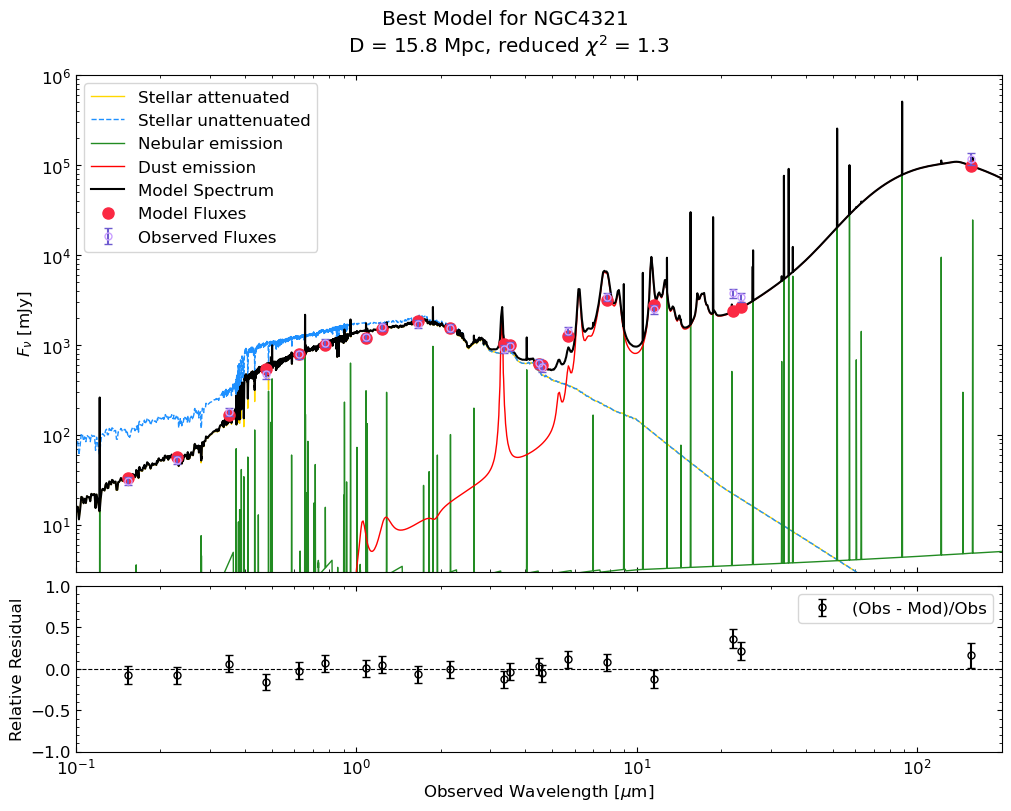

In [ ]:
fig = plt.figure(figsize=(10,8), constrained_layout=True)
ax = fig.subplot_mosaic(
    """
    aaa
    aaa
    aaa
    bbb
    """,
    gridspec_kw={'wspace': 0,
                 'hspace': 0}
)

mod_fluxes = np.array(
    [
        results_table[f'best.{filt}']
        if f'best.{filt}' in results_table.colnames
        else np.nan
        for filt in flux_columns
    ]
)

obs_flux = np.array(
    [
        cigale_observations[filt] if filt in cigale_observations.colnames else np.nan
        for filt in flux_columns
    ]
)

obs_err = np.array(
    [
        cigale_observations[filt] if filt in cigale_observations.colnames else np.nan
        for filt in error_columns
    ]
)

spectrum = best_sed_table['stellar.young'] + best_sed_table['stellar.old']
spectrum += best_sed_table['nebular.absorption_old']
spectrum += best_sed_table['nebular.absorption_young']
spectrum += best_sed_table['attenuation.stellar.old']
spectrum += best_sed_table['attenuation.stellar.young']

ax['a'].loglog(best_sed_table['wavelength'].to(u.um), spectrum,
               color='gold', ls='-', lw=1.0, nonpositive='clip', label='Stellar attenuated')

ax['a'].loglog(best_sed_table['wavelength'].to(u.um), best_sed_table['stellar.old'] + best_sed_table['stellar.young'],
               color='dodgerblue', ls='--', lw=1.0, nonpositive='clip', label='Stellar unattenuated')

spectrum = best_sed_table['nebular.emission_old'] + best_sed_table['nebular.emission_young']
spectrum += best_sed_table['attenuation.nebular.emission_old']
spectrum += best_sed_table['attenuation.nebular.emission_young']
ax['a'].loglog(best_sed_table['wavelength'].to(u.um), spectrum,
               color='forestgreen', ls='-', lw=1.0, nonpositive='clip', label='Nebular emission')

ax['a'].loglog(best_sed_table['wavelength'].to(u.um), best_sed_table['dust.Umin_Umin'] + best_sed_table['dust.Umin_Umax'],
               color='red', ls='-', lw=1.0, nonpositive='clip', label='Dust emission')

ax['a'].loglog(best_sed_table['wavelength'].to(u.um), best_sed_table['L_lambda_total'],
               color='k', ls='-', lw=1.5, nonpositive='clip', label='Model Spectrum')

ax['a'].plot(photometry_table['wavelength'].to(u.um), mod_fluxes,
             marker='o', color='xkcd:strawberry', ms=8, ls='None', label='Model Fluxes', zorder=3)

ax['a'].errorbar(photometry_table['wavelength'].to(u.um), obs_flux[:,0],
                 yerr=obs_err[:,0],
                 ls='None', marker='o', mfc='None', mec='xkcd:pastel purple', ms=5, capsize=3, zorder=3, ecolor='xkcd:light indigo',
                 label='Observed Fluxes')


ax['b'].errorbar(photometry_table['wavelength'].to(u.um),
                 ((obs_flux - mod_fluxes)/obs_flux)[:,0],
                 yerr=obs_err[:,0]/obs_flux[:,0],
                 marker='o', ms=5, mfc='None', ls='None', mec='k', capsize=3, ecolor='k', label='(Obs - Mod)/Obs')


ax['b'].tick_params(
    direction='in', axis='both', which='both', right=True, top=True
)

dist = results_table['best.universe.luminosity_distance'].to(u.Mpc)[0]
chi2 = results_table['best.reduced_chi_square'][0]
fig.suptitle(f'Best Model for {results_table['id'][0]}\n D = {dist:.1f}, reduced $\chi^2$ = {chi2:.1f}')

for a in ['a','b']:
    ax[a].set_xlim(1e-1,200)
    ax[a].tick_params(
            direction='in',
            axis='both',
            which='both',
            top=True,
            left=True,
            right=True,
            bottom=True
        )
    ax[a].legend(loc='best')

    if a == 'a':
        ax[a].set_ylim(3,1e6)
        ax[a].set_xticklabels([])
        ax[a].set_ylabel(r'$F_\nu$ [mJy]')
    if a == 'b':
        ax[a].set_xscale('log')
        ax[a].minorticks_on()
        ax[a].set_ylim(-1,1)
        ax[a].axhline(0, color='k', ls='--', lw=0.8)
        ax[a].set_ylabel(r'Relative Residual')
        ax[a].set_xlabel(r'Observed Wavelength [$\mu$m]')




plt.show()

## 18. The Star Formation History

The star formation history (SFH) tells us how the model star formation rate changes with time. We'll search the output directory for files with `sfh` in the name. 

In [145]:
possible_sfh_files = []

if cigale_out_dir.exists():
    for path in sorted(cigale_out_dir.glob('*')):
        lower_name = path.name.lower()

        if 'sfh' in lower_name and path.suffix.lower() in ['.fits', '.txt']:
            possible_sfh_files.append(path)

print('Possible SFH files:\n')
for path in possible_sfh_files:
    print(path.name)

Possible SFH files:

NGC4321_SFH.fits


In [146]:
# Choose the first file by default
# Change this if necessary
if len(possible_sfh_files) > 0:
    best_sfh_file = possible_sfh_files[0]
    print(f'Using best-fit SED file: {best_sfh_file}')
else:
    best_sfh_file = None
    print('No best-fit SFH file found.')
    print('Check whether save_best_sed = True in pcigale.ini.')

Using best-fit SED file: cigale_run/out/NGC4321_SFH.fits


In [147]:
# Inspect the file structure
if best_sfh_file is not None:
    with fits.open(best_sfh_file) as hdul:
        hdul.info()

        print('\nTable extensions and columns:\n')
        for hdu_index, hdu in enumerate(hdul):
            if hasattr(hdu, 'columns') and hdu.columns is not None:
                print(f'HDU {hdu_index}: {hdu.name}')
                print(hdu.columns.names)
                print()

Filename: cigale_run/out/NGC4321_SFH.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     76   12500R x 2C   [K, D]   

Table extensions and columns:

HDU 1: 
['time', 'SFR']



In [150]:
sfh_table = None

if best_sfh_file is None:
    print("No SFH source file found.")
else:
    suffix = best_sfh_file.suffix.lower()

    if suffix in [".fits", ".fit"]:
        try:
            sfh_table = QTable.read(best_sfh_file, hdu=1)
            print(f"Loaded SFH table from {best_sfh_file}, HDU 1")
        except Exception as err:
            print("Could not read the requested SFH HDU.")
            print(err)

    elif suffix in [".txt", ".dat"]:
        try:
            sfh_table = QTable.read(best_sfh_file, format="ascii")
            print(f"Loaded SFH table from {best_sfh_file}")
        except Exception as err:
            print("Could not read the SFH text file.")
            print(err)

if sfh_table is not None:
    print("\nSFH columns:\n")

    for col in sfh_table.colnames:
        print(col)

    sfh_table.pprint(max_lines=5)

Loaded SFH table from cigale_run/out/NGC4321_SFH.fits, HDU 1

SFH columns:

time
SFR
  time         SFR       
  Myr      solMass / yr  
------- -----------------
    0.0 5.113840136855723
    ...               ...
12498.0 2.222762110593494
12499.0 2.222613931392149
Length = 12500 rows


## 20. Plot the star-formation history

The SFH is model-dependent.

It is not directly observed in the same way as a flux measurement. It depends on:

- the chosen SFH module,
- the parameter grid,
- the stellar population model,
- dust attenuation assumptions,
- and the photometry.

Still, it is useful for visualizing what kind of formation history CIGALE selected.

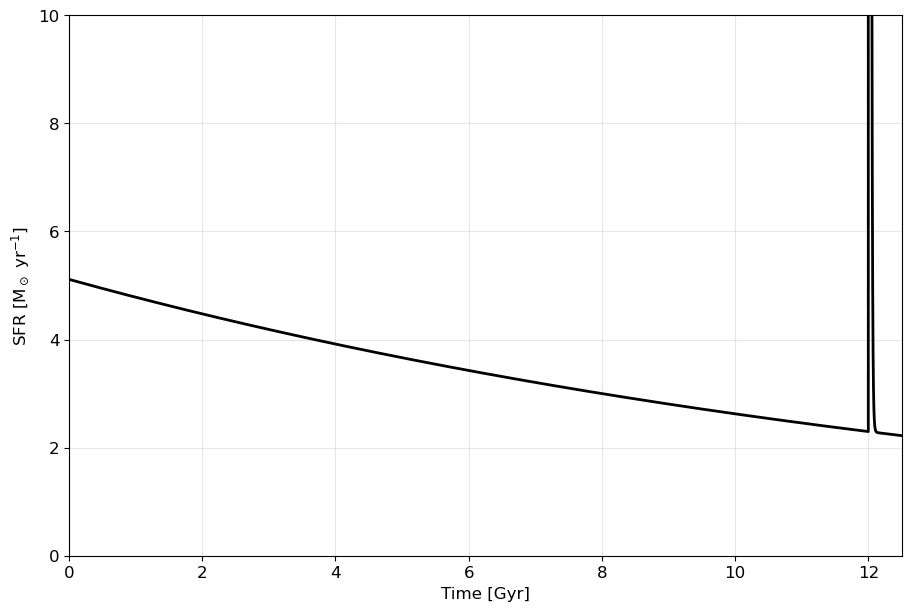

In [157]:
fig = plt.figure(figsize=(9, 6), constrained_layout=True)
ax = plt.subplot(111)

ax.plot(sfh_table['time']/1e3, sfh_table['SFR'],
        color='k', ls='-', lw=2)

ax.set_ylim(0,10)
ax.set_xlim(0,12.5)
ax.set_xlabel(r'Time [Gyr]')
ax.set_ylabel(r'SFR [M$_\odot$ yr$^{-1}$]')
ax.grid(alpha=0.3)
plt.show()